<a href="https://colab.research.google.com/github/TanmayGupta2005/Data_analysis_project2/blob/main/Copy_of_Data_anal_proj_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'data_anal_proj1.xlsx', 'sample_data']


Loading the Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel('data_anal_proj1.xlsx')
print("Firat five rows:")
print(df.head())

Firat five rows:
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70

In [ ]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(1200, 14)


In [ ]:
print("Column Names:")
print(df.columns)

Column Names:
Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')


In [ ]:
print("Datatypes:")
print(df.dtypes)

Datatypes:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object


2. Basic Statistics

In [ ]:
print("basic statistics:")
print(df.describe)

basic statistics:
<bound method NDFrame.describe of         OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0     ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1     ORD200001 2024-08-23     C75739    Phone         2     151.35   
2     ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3     ORD200003 2023-10-15     C33540    Chair         1     273.19   
4     ORD200004 2025-05-08     C81840  Printer         4     626.01   
...         ...        ...        ...      ...       ...        ...   
1195  ORD201195 2024-06-20     C21126     Desk         1     107.04   
1196  ORD201196 2024-03-04     C20095  Monitor         2     662.53   
1197  ORD201197 2023-07-13     C79674   Tablet         2     436.84   
1198  ORD201198 2024-08-22     C64753    Chair         4     262.52   
1199  ORD201199 2023-06-11     C57502   Tablet         4     560.58   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0        928 Main

In [ ]:
print("mean:")
print(df.mean(numeric_only=True))

mean:
Quantity          2.945833
UnitPrice       356.412750
ItemsInCart       5.485000
TotalPrice     1053.968300
dtype: float64


In [ ]:
print("median:")
print(df.median(numeric_only=True))

median:
Quantity         3.000
UnitPrice      364.210
ItemsInCart      5.000
TotalPrice     823.615
dtype: float64


In [ ]:
print("count")
print(df.count())

count
OrderID            1200
Date               1200
CustomerID         1200
Product            1200
Quantity           1200
UnitPrice          1200
ShippingAddress    1200
PaymentMethod      1200
OrderStatus        1200
TrackingNumber     1200
ItemsInCart        1200
CouponCode          891
ReferralSource     1200
TotalPrice         1200
dtype: int64


3. Missing Values

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


4. Outlier detection

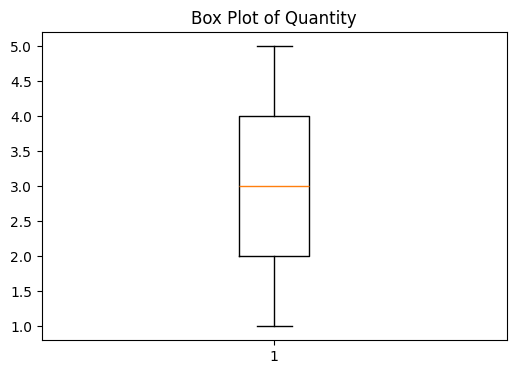

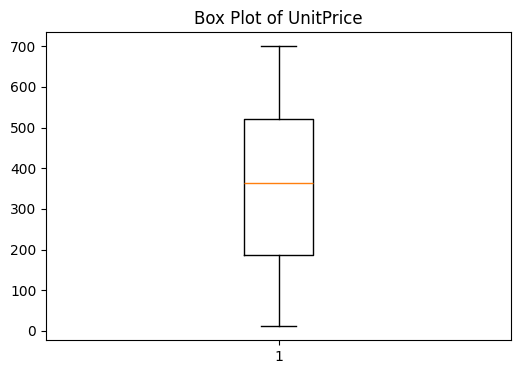

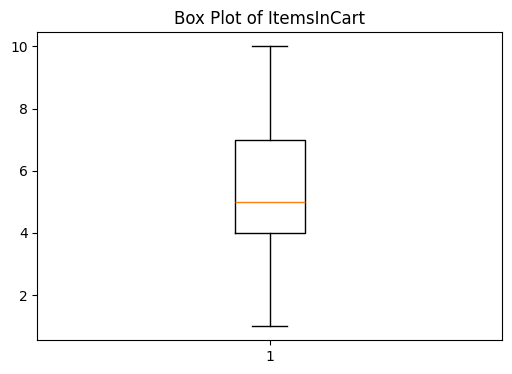

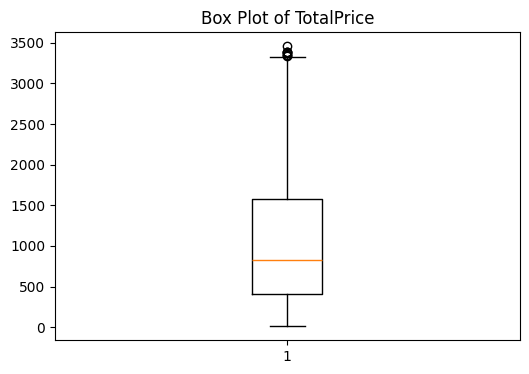

In [ ]:
numeric_columns = df.select_dtypes(include='number')
for column in numeric_columns.columns:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[column].dropna())
    plt.title(f"Box Plot of {column}")
    plt.show()

5. Distribution

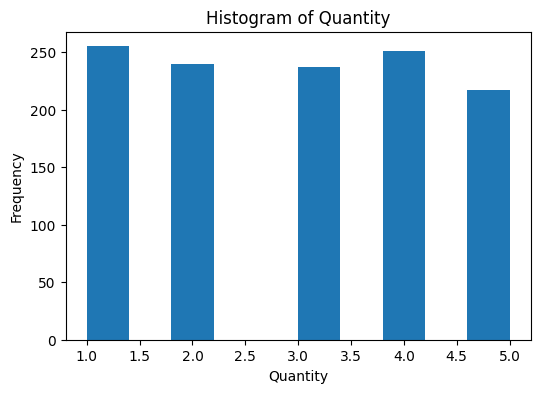

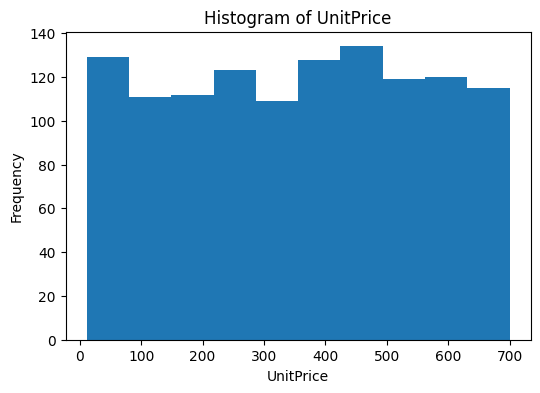

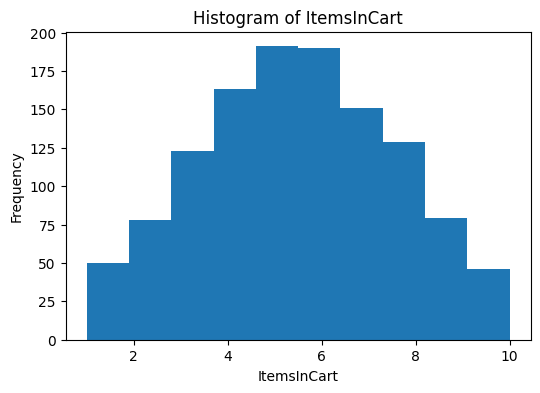

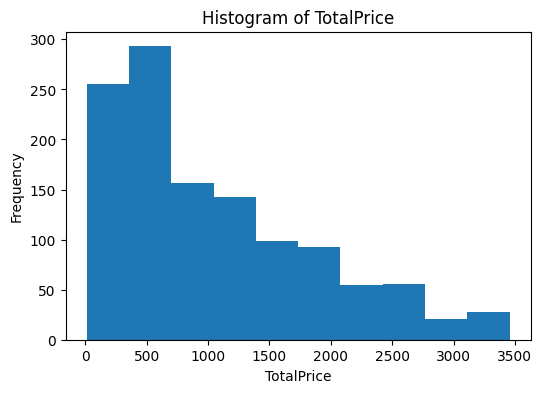

In [ ]:
for column in numeric_columns.columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[column], bins=10)
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()


6. Trend Analsis

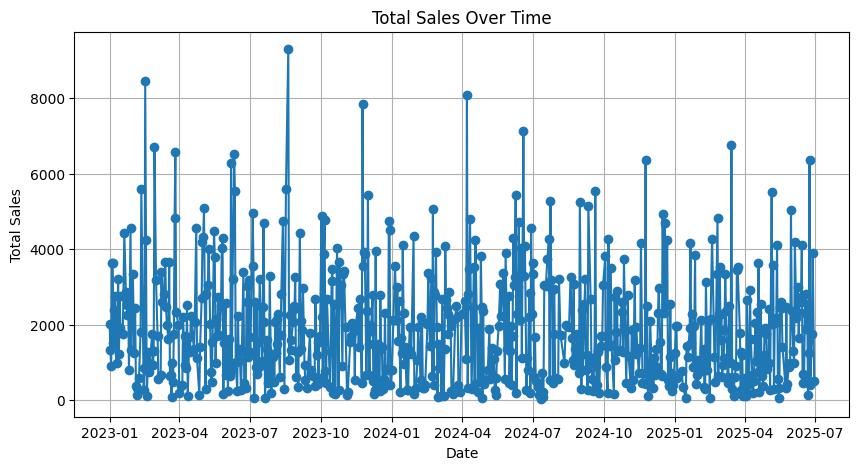

In [ ]:
if "Date" in df.columns and "TotalPrice" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])

    daily_sales = df.groupby("Date")["TotalPrice"].sum()

    plt.figure(figsize=(10,5))
    plt.plot(daily_sales.index, daily_sales.values, marker='o')
    plt.title("Total Sales Over Time")
    plt.xlabel("Date")
    plt.ylabel("Total Sales")
    plt.grid(True)
    plt.show()

7. Correlation

In [ ]:
print("\nCorrelation Matrix:")
print(numeric_columns.corr())


Correlation Matrix:
             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity     1.000000   0.014553     0.650061    0.615251
UnitPrice    0.014553   1.000000     0.000602    0.717081
ItemsInCart  0.650061   0.000602     1.000000    0.392540
TotalPrice   0.615251   0.717081     0.392540    1.000000


8.Summary

In [ ]:
print("\n===== EDA SUMMARY =====")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Missing Values: {df.isnull().sum().sum()}")

print("\nStatistics:")
print(numeric_columns.describe())


===== EDA SUMMARY =====
Rows: 1200
Columns: 14
Missing Values: 309

Statistics:
          Quantity    UnitPrice  ItemsInCart   TotalPrice
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750     5.485000  1053.968300
std       1.407557   197.177146     2.281983   819.856558
min       1.000000    11.390000     1.000000    11.390000
25%       2.000000   186.062500     4.000000   410.520000
50%       3.000000   364.210000     5.000000   823.615000
75%       4.000000   521.570000     7.000000  1578.475000
max       5.000000   699.930000    10.000000  3456.400000
